Computing recurrence intervals for IMERG time series at Hunt, Texas

Extreme value analysis (EVA) methods:
    1. Block Maxima (BM) 
    2. Peaks Over Threshold (POT)

Jacob R. Schaperow
Andrew M. Fisher 

In [1]:
# Import packages

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pyextremes import EVA

In [2]:
# Import time series data

df = pd.read_csv('./Data/hunt_texas_IMERG_daily.txt')
df.columns = ['date','precip_mm']
print(df.head())

ds_series = df.set_index('date')['precip_mm']
print(ds_series.head())

ds_series.index = pd.to_datetime(ds_series.index)

         date  precip_mm
0  1998-01-01      0.000
1  1998-01-02      0.000
2  1998-01-03      0.085
3  1998-01-04      0.000
4  1998-01-05      0.000
date
1998-01-01    0.000
1998-01-02    0.000
1998-01-03    0.085
1998-01-04    0.000
1998-01-05    0.000
Name: precip_mm, dtype: float64


In [3]:
# Clean data

# Remove zeros
df_noz = ds_series[ds_series>0]
print(df_noz.head())
print(len(df_noz))
print(len(ds_series))

# Remove trends, etc. if needed

date
1998-01-03     0.085
1998-01-06    27.195
1998-01-07     0.755
1998-01-20     0.260
1998-01-22     1.305
Name: precip_mm, dtype: float64
3221
10135


In [ ]:
# Create model for the time series data
# Block Maxima (BM) 

model = EVA(ds_series)
out = model.get_extremes(method = "BM", block_size="365.2425D")
print(out)
print(model.extremes)
model.plot_extremes()

date
1998-01-06    27.195
1998-01-07     0.755
1998-01-22     1.305
1998-01-31    20.385
1998-02-02     8.270
Name: precip_mm, dtype: float64


(<Figure size 768x480 with 1 Axes>, <Axes: xlabel='date', ylabel='precip_mm'>)

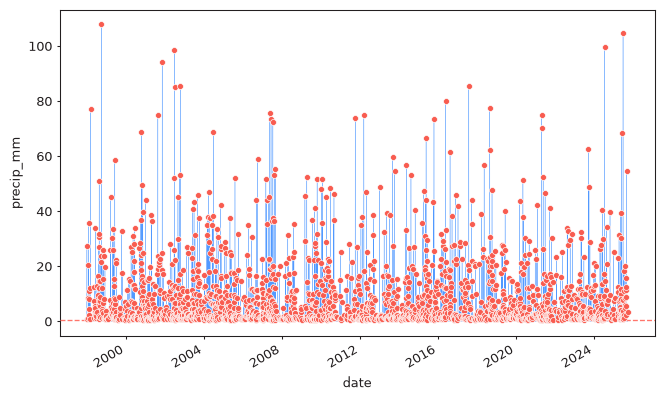

In [4]:
# Peaks Over Threshold (POT)
model = EVA(ds_series)
model.get_extremes("POT", threshold=0.5, r="12h")
print(model.extremes.head())
model.plot_extremes(show_clusters=True)

In [ ]:
# Fit a model to the extreme values

model.fit_model() # default fitting method is MLE
print(model)

model.plot_diagnostic(alpha=0.95)

model.plot_return_values(
    return_period = np.logspace(0.01,2,100),
    return_period_size = "365.2425D",
    alpha = 0.95
)

In [ ]:
# Estimate return values

summary = model.get_summary(
    return_period=[1, 2, 5, 10, 25, 50, 100],
    alpha=0.95,
    n_samples=1000,
)
print(summary)

In [ ]:

# Plot histogram (with zeros)

df['precip_mm'].hist(bins = 50, edgecolor='black')
plt.title('Precipitation histogram')
plt.xlabel('Precip (mm/day)')
plt.ylabel('Count')

In [ ]:
# Plot histogram (without zeros)

df_noz = df[df['precip_mm']>0]
p95 = np.percentile(df_noz['precip_mm'], 95) # calculate 95% precipitation

df_noz['precip_mm'].hist(bins = "fd", edgecolor='black')
plt.axvline(x = p95, 
    color = "black", 
    linewidth = 2, 
    label=f"95th percentile precip: ({p95:.2f} mm)"
)

plt.title('Precipitation histogram (zeros excluded)')
plt.xlabel('Precip (mm/day)')
plt.ylabel('Count')
plt.legend()



In [ ]:
# Implement annual maximum method



In [ ]:
# Implement peak-over-threshold (POT) method

# Choosing threshold of p95 for peak-over-threshold method
threshold = p95 # this might be too low...

# Get precipitation data over the threshold value
df_peaks = df_noz[df_noz['precip_mm']>threshold]
df_peaks.head()
print(len(df_peaks))

df_excesses = df_peaks['precip_mm'] - threshold

# Plot histogram of extreme values
df_excesses.hist(bins = "fd", edgecolor = "black")
plt.title('Histogram of precipitation excesses over threshold')
plt.xlabel('Precip (mm/day)')
plt.ylabel('Count')

# We should implement a check to remove consecutive peaks that are actually part of the same storm event
# For example, ensure there is at least one full day in between peaks
# This will help with independence, and satisfying the extreme value theorem, which requires i.i.d. random variables


In [ ]:
# Select a threshold

